<img src="MUML_header.svg" alt="Header" style="width:100%; height:auto;">

# 01_01 Warm-up and first model

In this notebook you will:

* Recap the basics of NumPy: arrays, shapes, broadcasting, and vectorized operations.
* Practice Pandas for data handling: loading a dataset, inspecting it, selecting columns/rows, and computing simple statistics.
* Practice plotting with Matplotlib: simple scatter plots and histograms.

* Train your first machine learning model in this Master's: a k-Nearest Neighbors (kNN) classifier, using scikit-learn. You will also compare its performance with a simple baseline and understand the importance of preprocessing (scaling).

## The basics of NumPy

### 1) Creating arrays and dtypes  

NumPy’s core object is the **ndarray** (N-dimensional array).  
An array is:  

- **Homogeneous**: all elements have the same data type (`dtype`).  
- **Efficient**: stored in contiguous memory for fast operations.  

There are several ways to create arrays:  

1. **From Python lists or tuples**: wrap them with `np.array()`.  
2. **With constructors**: `np.zeros`, `np.ones`, `np.arange`, `np.linspace`.  
3. **Random generators**:  
   - `np.random.rand(m, n)` → uniform in [0, 1).  
   - `np.random.randn(m, n)` → standard normal (mean 0, variance 1).  

Each array has attributes like `.shape`, `.dtype`, `.ndim`, which describe its structure.  


In [1]:
import numpy as np

# 1) From lists
a = np.array([1, 2, 3])                # default dtype = int
b = np.array([1.0, 2.0, 3.0])          # dtype = float

# 2) Constructors
z = np.zeros((2, 3))                   # 2x3 zeros, float64 by default
o = np.ones((3, 2), dtype=np.int32)    # 3x2 ones, explicitly int32
ar = np.arange(0, 10, 2)               # 0, 2, 4, 6, 8
ls = np.linspace(0, 1, 5)              # 5 evenly spaced values between 0 and 1

# 3) Random arrays
u = np.random.rand(2, 4)               # uniform [0,1), shape (2,4)
n = np.random.randn(3, 3)              # standard normal, shape (3,3)

print("a:", a, "dtype:", a.dtype, "shape:", a.shape)
print("b:", b, "dtype:", b.dtype, "shape:", b.shape)
print("zeros:\n", z)
print("ones:\n", o)
print("arange:", ar)
print("linspace:", ls)
print("uniform rand:\n", u)
print("normal rand:\n", n)


a: [1 2 3] dtype: int64 shape: (3,)
b: [1. 2. 3.] dtype: float64 shape: (3,)
zeros:
 [[0. 0. 0.]
 [0. 0. 0.]]
ones:
 [[1 1]
 [1 1]
 [1 1]]
arange: [0 2 4 6 8]
linspace: [0.   0.25 0.5  0.75 1.  ]
uniform rand:
 [[0.6424554  0.32404613 0.11391684 0.95760256]
 [0.4773382  0.59806104 0.08742741 0.43309504]]
normal rand:
 [[-0.57169132  0.00809801  0.84765616]
 [ 0.63474916  0.90338002 -0.76613402]
 [-1.11674971  0.19111509  1.8217199 ]]


### 2) Shapes, dimensions, and reshape  

Each array has:  
- `.shape` → tuple of dimensions (rows, columns, …).  
- `.ndim` → number of dimensions.  
- `.size` → total number of elements.  

You can **reshape** arrays to different shapes as long as the total number of elements is preserved.  
Use `.reshape()` to create a new view, and `.ravel()` (view) or `.flatten()` (copy) to turn arrays into 1D.  


In [2]:
# Shapes and dimensions
X = np.random.randn(4, 3)   # 4 rows, 3 columns
print("Shape:", X.shape, "ndim:", X.ndim, "size:", X.size)

# Reshape
v = np.arange(12)           # 1D vector of length 12
V = v.reshape(3, 4)         # reshape into 3x4
print("V:\n", V)

# Flatten vs ravel
flat1 = V.ravel()           # view (shares memory)
flat2 = V.flatten()         # copy (independent)

flat1[0] = 999
print("After modifying ravel(), V:\n", V)  # changed because ravel is a view

flat2[0] = -999
print("After modifying flatten(), V (unchanged):\n", V)


Shape: (4, 3) ndim: 2 size: 12
V:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
After modifying ravel(), V:
 [[999   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]]
After modifying flatten(), V (unchanged):
 [[999   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]]


### 3) Indexing, slicing, and boolean masks  

NumPy indexing is powerful:  
- **Slicing**: `X[start:end]` works like Python lists (end exclusive).  
- **2D indexing**: `X[rows, cols]`.  
- **Boolean masks**: use a condition to select elements.  

Important: slices are usually **views**, not copies.  


In [3]:
X = np.random.randn(4, 5)
print("X:\n", X)

# Slice rows 0–1, columns 2–4 (end exclusive)
sub = X[0:2, 2:5]
print("sub:\n", sub, "\n(sub is a view -> shares memory with X):", sub.base is X)

# Boolean mask: select rows where first column > 0
mask = X[:, 0] > 0
print("mask:", mask)
print("rows with first column > 0:\n", X[mask])

# Fancy indexing: pick specific rows/cols
rows = np.array([0, 2])
cols = np.array([1, 3, 4])
print("fancy selection X[rows][:, cols]:\n", X[rows][:, cols])


X:
 [[ 0.98866224  0.48131495  1.48750083 -0.54003925  0.74083585]
 [ 0.49498043  1.35534486 -1.45675932  0.68992326 -1.04211939]
 [ 2.2404149  -0.51615125  0.6087115  -0.2642965   0.37686201]
 [ 0.2768573   0.90259091  0.49612456 -1.67477321 -1.02837832]]
sub:
 [[ 1.48750083 -0.54003925  0.74083585]
 [-1.45675932  0.68992326 -1.04211939]] 
(sub is a view -> shares memory with X): True
mask: [ True  True  True  True]
rows with first column > 0:
 [[ 0.98866224  0.48131495  1.48750083 -0.54003925  0.74083585]
 [ 0.49498043  1.35534486 -1.45675932  0.68992326 -1.04211939]
 [ 2.2404149  -0.51615125  0.6087115  -0.2642965   0.37686201]
 [ 0.2768573   0.90259091  0.49612456 -1.67477321 -1.02837832]]
fancy selection X[rows][:, cols]:
 [[ 0.48131495 -0.54003925  0.74083585]
 [-0.51615125 -0.2642965   0.37686201]]


### 4) Broadcasting  

Broadcasting allows NumPy to apply operations on arrays of different shapes.  
Rules:  
- Dimensions are compared from right to left.  
- If they match or one of them is 1, broadcasting is possible.  

Common ML use: **standardizing features** by subtracting column means and dividing by column stds.  


In [4]:
X = np.random.randn(6, 4)

# Column means and stds (axis=0). keepdims=True to keep 2D shape for broadcasting.
col_means = X.mean(axis=0, keepdims=True)
col_stds  = X.std(axis=0, keepdims=True) + 1e-12  # avoid divide-by-zero

X_std = (X - col_means) / col_stds

print("Original means:", X.mean(axis=0))
print("Standardized means (≈0):", X_std.mean(axis=0))
print("Standardized stds  (≈1):", X_std.std(axis=0))


Original means: [-0.25219997 -0.88843348 -0.17628538  0.25292581]
Standardized means (≈0): [3.70074342e-17 1.11022302e-16 0.00000000e+00 9.25185854e-17]
Standardized stds  (≈1): [1. 1. 1. 1.]


### 5) Reductions and the `axis` argument  

NumPy functions like `sum`, `mean`, `std`, or `max` can reduce an array along a chosen axis.  

- `axis=0` → operate *down the rows* (column-wise).  
- `axis=1` → operate *across the columns* (row-wise).  

Examples:  
- Column means: `X.mean(axis=0)` → one value per feature.  
- Row norms: `np.linalg.norm(X, axis=1)` → one value per sample.  


In [5]:
X = np.random.randn(5, 3)

# Column-wise reductions (one per feature)
col_means = X.mean(axis=0)
col_max   = X.max(axis=0)

# Row-wise reductions (one per sample)
row_sums  = X.sum(axis=1)
row_norms = np.linalg.norm(X, axis=1)  # L2 norm per row

print("Column means:", col_means)
print("Column max:", col_max)
print("Row sums:", row_sums)
print("Row L2 norms:", row_norms)


Column means: [ 0.5742745  -0.09817221 -0.15970732]
Column max: [1.528175   1.54652723 0.41573472]
Row sums: [ 2.37759369 -1.57692323 -0.53011755  1.1251148   0.18630714]
Row L2 norms: [1.64202192 2.22395939 0.40027629 1.65629166 0.65333559]


### 6) Elementwise vs. matrix multiplication  

- `*` in NumPy is **elementwise multiplication** (Hadamard product).  
- `@` (or `np.dot`) is **matrix multiplication**.  

This distinction is critical in ML:  
- Use elementwise ops for feature scaling, normalization, etc.  
- Use matrix multiplication for linear models and transformations.  
 


In [6]:
A = np.random.randn(2, 3)
B = np.random.randn(3, 4)

elem = A * A            # elementwise (Hadamard) product
matm = A @ B            # matrix product

print("A shape:", A.shape, "B shape:", B.shape)
print("elementwise A*A shape:", elem.shape)
print("matrix A@B shape:", matm.shape)


A shape: (2, 3) B shape: (3, 4)
elementwise A*A shape: (2, 3)
matrix A@B shape: (2, 4)


### 7) Concatenation & stacking  

NumPy lets you join arrays along rows or columns:  

- **Horizontal stacking** (`np.hstack`) → adds more features (columns).  
- **Vertical stacking** (`np.vstack`) → adds more samples (rows).  
- **Concatenate** (`np.concatenate`) → more general, specify axis directly.  

Always check shapes before stacking — mismatched dimensions will raise errors.  


In [7]:
# Horizontal stacking: add features (columns)
X1 = np.random.randn(4, 2)
X2 = np.random.randn(4, 3)
Xh = np.hstack([X1, X2])        # (4, 5)

# Vertical stacking: add samples (rows)
Y1 = np.random.randn(2, 5)
Y2 = np.random.randn(3, 5)
Yv = np.vstack([Y1, Y2])        # (5, 5)

# General concatenate
cat0 = np.concatenate([X1, X2[:, :2]], axis=1)  # along columns
cat1 = np.concatenate([Y1, Y2[:2, :]], axis=0)  # along rows

print("Xh shape:", Xh.shape)
print("Yv shape:", Yv.shape)
print("concatenate axis=1 shape:", cat0.shape)
print("concatenate axis=0 shape:", cat1.shape)


Xh shape: (4, 5)
Yv shape: (5, 5)
concatenate axis=1 shape: (4, 4)
concatenate axis=0 shape: (4, 5)


### 8) Vectorization demo: pairwise squared distances  

A key advantage of NumPy is replacing slow Python loops with **vectorized operations**.  
Example: compute pairwise squared distances between two sets of vectors.  

Mathematical trick:  
$$
\|x - y\|^2 = \|x\|^2 + \|y\|^2 - 2 \, x \cdot y
$$

This allows computing all distances at once with broadcasting and matrix multiplication.  
This pattern is the basis for efficient implementations of k-Nearest Neighbors (kNN).  


In [8]:
# Given X (m,d) and Y (n,d), compute D_ij = ||X_i - Y_j||^2 without Python loops
X = np.random.randn(5, 3)
Y = np.random.randn(6, 3)

# Trick: ||x - y||^2 = ||x||^2 + ||y||^2 - 2 x·y
X2 = np.sum(X**2, axis=1, keepdims=True)      # (5,1)
Y2 = np.sum(Y**2, axis=1, keepdims=True).T    # (1,6)
XY = X @ Y.T                                   # (5,6)
D2 = X2 + Y2 - 2 * XY                          # (5,6)

print("Pairwise squared distances shape:", D2.shape)
print(D2[:2, :3])


Pairwise squared distances shape: (5, 6)
[[10.18107154  2.57173723  2.26534465]
 [ 4.54482063  7.4640582   3.64113686]]


### 9) NaN-aware reductions  

Real datasets often contain **missing values** represented as `np.nan`.  
Normal reductions (`mean`, `sum`, etc.) will return `nan` if any value is missing.  

NumPy provides **nan-safe versions** that ignore `nan` values:  
- `np.nanmean`, `np.nanstd`, `np.nansum`, etc.  

Useful when exploring raw data before cleaning.  


In [9]:
X = np.random.randn(4, 3)
X[1, 2] = np.nan
X[3, 0] = np.nan

print("mean (propagates NaN):", X.mean())
print("nanmean (ignores NaN):", np.nanmean(X))

print("col-wise std with NaN:", X.std(axis=0))
print("col-wise nanstd:", np.nanstd(X, axis=0))


mean (propagates NaN): nan
nanmean (ignores NaN): 0.09319653477324473
col-wise std with NaN: [       nan 1.50516594        nan]
col-wise nanstd: [0.61306573 1.50516594 0.60360335]


### 10) Common pitfalls with NumPy arrays  

- **Shape errors**: always keep data as `(n_samples, n_features)`.  
- **Views vs. copies**: slices are views; use `.copy()` when independence is needed.  
- **Broadcasting surprises**: check shapes with `.shape` and use `keepdims=True` when reducing.  
- **Dtypes matter**: integer vs float can change division or rounding behavior.  
- **Looping in Python**: avoid explicit for-loops; prefer vectorized NumPy operations.  
- **Randomness**: results differ each run with `np.random`; fix with `np.random.seed(...)` if reproducibility is needed.  


In [10]:
# Views vs copies
A = np.arange(12).reshape(3, 4)
view = A[:, :2]          # view
view[0, 0] = 999
print("A changed via view?\n", A)

copy = A[:, :2].copy()   # copy
copy[0, 0] = -999
print("A unchanged after modifying copy?\n", A)

# Broadcasting gotchas: check shapes
X = np.random.randn(5, 3)
col_mean = X.mean(axis=0, keepdims=True)  # shape (1,3) → safe to subtract from (5,3)
X_centered = X - col_mean
print("Shapes:", X.shape, col_mean.shape, X_centered.shape)

# Integer vs float dtype
ints = np.array([1, 2, 3], dtype=np.int32)
floats = np.array([1, 2, 3], dtype=np.float64)
print("ints / 2:", ints / 2)       # upcasts to float64
print("floats / 2:", floats / 2)


A changed via view?
 [[999   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]]
A unchanged after modifying copy?
 [[999   1   2   3]
 [  4   5   6   7]
 [  8   9  10  11]]
Shapes: (5, 3) (1, 3) (5, 3)
ints / 2: [0.5 1.  1.5]
floats / 2: [0.5 1.  1.5]


## Exercises

Solve the following, using only NumPy (no loops unless asked).


#### Exercise 1
Given a 6×4 array `X` of standard normal numbers, select all rows where the **sum across columns** is positive. Return the filtered array.


#### Exercise 2
Let `X` be shape (5, 3) and `Y` be shape (4, 3). Compute the **pairwise squared Euclidean distances** between every row of `X` and every row of `Y` **without Python loops**. Result shape: (5, 4).

#### Exercise 3
Create `X1` of shape (4,2) and `X2` of shape (4,3) with random numbers.  
- Concatenate **horizontally** → shape (4,5).  
Create `Y1` of shape (2,5) and `Y2` of shape (3,5).  
- Concatenate **vertically** → shape (5,5).



#### Exercise 4
Create a 8×3 array `Z` with numbers following a normal distribution with mean 2 and standard deviation 0.6. Take two random positions of the array and set them to np.nan.  
- Compute the **overall mean** with `np.mean` (will be `nan`).  
- Compute it again with `np.nanmean`.

#### Exercise 5
For a random 8×4 array `X`, subtract the **column means** and divide by the **column stds** using broadcasting (no loops). Verify the standardized columns have mean ≈ 0 and std ≈ 1.

#### Exercise 6

Create a 6×6 array `A` of random numbers from the standard normal distribution.

1. Compute the **column means** of `A`.  
2. Subtract the column mean from each element **only if** the element is **positive**.  
   - Negative values should remain unchanged.  

Use a **boolean mask** and **broadcasting**, no loops.


#### Exercise 7

You are given a matrix of **integer scores** `S` with shape `(6, 5)`.  
Create `S` with random integers in `[0, 10)` (dtype should be integer) and, using  `argmax` and **fancy indexing**, extract the **maximum score per row** into a vector `vmax`.


## Pandas Guided Walkthrough

### Pandas Basics with a Dataset  

Pandas provides two main data structures:  

- **Series**: one-dimensional labeled array.  
- **DataFrame**: two-dimensional table (like a spreadsheet), with labeled rows and columns.  

We will practice Pandas on the **Iris dataset** (flower measurements with 3 species).  

Typical workflow:  
1. Load dataset into a DataFrame.  
2. Inspect structure (rows, columns, types).  
3. Select/filter rows and columns.  
4. Compute simple statistics.  
5. Group by categories and aggregate.  


In [11]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)  # returns a sklearn Bunch with a DataFrame
df = iris.frame                  # features + target
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))  # nicer labels

df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Inspecting a DataFrame  

Useful methods to understand the dataset:  

- `df.head()` → first 5 rows.  
- `df.info()` → column names, dtypes, non-null counts.  
- `df.describe()` → summary statistics for numeric columns.  
- `df['col'].value_counts()` → counts of categories/labels.  


In [12]:
## Extract useful information about the dataset


### Selecting data  

Ways to select from a DataFrame:  

- **Column(s)**:  
  - `df['col']` → single column (Series).  
  - `df[['col1', 'col2']]` → multiple columns (DataFrame).  

- **Row slices**:  
  - `df.iloc[0:3]` → first 3 rows (position-based).  
  - `df.loc[0:3]` → rows with index labels 0 to 3.  

- **Boolean masks**:  
  - `df[df['sepal length (cm)'] > 5.0]` → filter by condition.  


In [13]:
## 1) Print the series containing the information regarding sepal lengths only
## 2) Print the dataframe containing the information regarding sepal and petal lengths only
## 3) Print the rows with sepal length > 5.0


### Grouping and aggregation  

Pandas makes it easy to compute statistics per group:  

- `df.groupby('col').mean()` → mean of each numeric column per group.  
- `df.groupby('col')['othercol'].agg(['mean', 'std'])` → multiple aggregations.  
- `df.groupby('col').size()` → count per group.  

Very common in ML for summarizing data per class/label.  


In [14]:
## 1) Obtain the mean of all numeric features per species
## 2) Obtain the mean + std of petal length per species
## 3) Count how many examples per class there are


## Plotting with Matplotlib

### Introduction to Matplotlib  

Matplotlib is Python’s standard library for plotting.  

We will use it to:  
- Plot **scatter plots** for relationships between features.  
- Plot **histograms** to see distributions.  
- Add **titles, axis labels, and legends** for clarity.  

These skills are essential for exploring datasets before applying ML.  


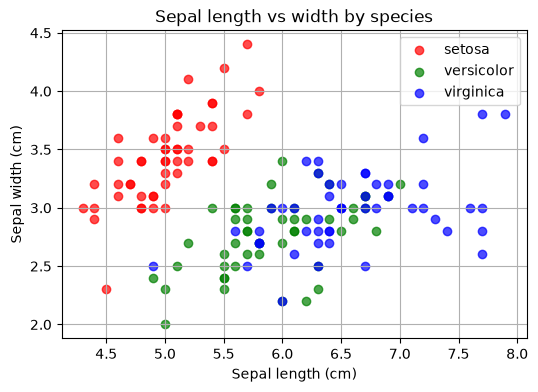

In [23]:
import matplotlib.pyplot as plt

# Scatter: sepal length vs sepal width, color by species
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

plt.figure(figsize=(6, 4))
for species, subset in df.groupby('species'):
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'],
                label=species, color=colors[species], alpha=0.7)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Sepal length vs width by species")
plt.legend()
plt.grid(True)
plt.show()


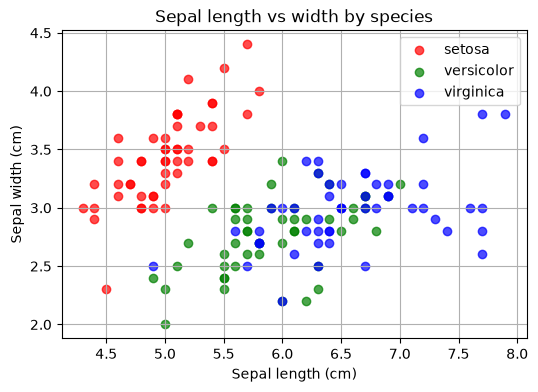

In [16]:
import matplotlib.pyplot as plt

# Scatter: sepal length vs sepal width, color by species
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}

plt.figure(figsize=(6, 4))
for species, subset in df.groupby('species'):
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'],
                label=species, color=colors[species], alpha=0.7)

plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Sepal length vs width by species")
plt.legend()
plt.grid(True)
plt.show()


### Histograms  

Histograms show the distribution of a single feature.  
- `plt.hist` creates bins (intervals) and counts how many samples fall into each.  
- You can control the number of bins with `bins=`.  


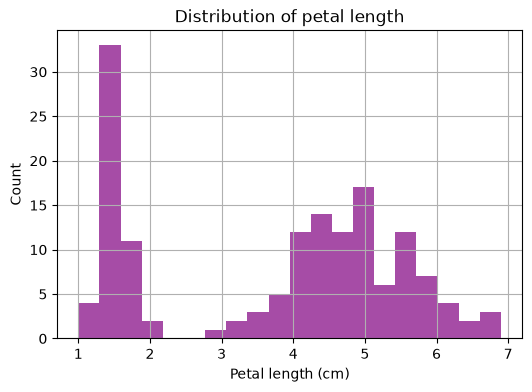

In [17]:
plt.figure(figsize=(6, 4))
plt.hist(df['petal length (cm)'], bins=20, color='purple', alpha=0.7)
plt.xlabel("Petal length (cm)")
plt.ylabel("Count")
plt.title("Distribution of petal length")
plt.grid(True)
plt.show()


### Multiple subplots  

We can place several plots side by side using `plt.subplots`.  
This is useful for comparing different features at once.  


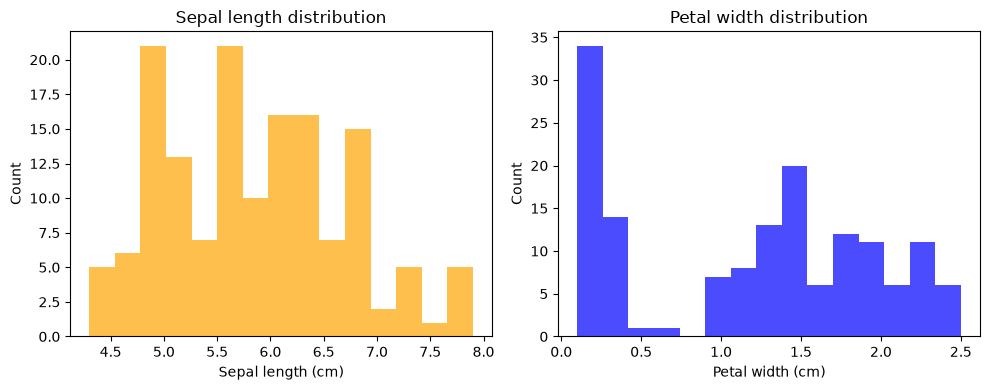

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram of sepal length
axes[0].hist(df['sepal length (cm)'], bins=15, color='orange', alpha=0.7)
axes[0].set_xlabel("Sepal length (cm)")
axes[0].set_ylabel("Count")
axes[0].set_title("Sepal length distribution")

# Histogram of petal width
axes[1].hist(df['petal width (cm)'], bins=15, color='blue', alpha=0.7)
axes[1].set_xlabel("Petal width (cm)")
axes[1].set_ylabel("Count")
axes[1].set_title("Petal width distribution")

plt.tight_layout()
plt.show()


### Exercises

#### Exercise 1

Use the Iris dataset (`df`) from earlier.
- Make a scatter plot of **petal length vs petal width**.  
- Encode the **species** with different **colors**.   
- Add axis labels, a title, and a legend.  


#### Exercise 2

Using the Iris dataset (`df`):

- Plot histograms of **petal length** for the three species, all in the **same plot**.  
- Use different colors and add a legend.  
- Set the number of bins to 20.  
- Make the plot semi-transparent so the distributions overlap visibly.  



#### Exercise 3

Using the Iris dataset (`df`):

- Create a figure with **2 rows and 2 columns of subplots**.  
- In each subplot, plot a histogram for one of the features:
  - Sepal length
  - Sepal width
  - Petal length
  - Petal width
- Add titles to each subplot with the feature name.  
- Adjust the layout so labels don’t overlap (`plt.tight_layout()`).


## First ML model with scikit-learn

### What is scikit-learn?  

[scikit-learn](https://scikit-learn.org/stable/) is one of the most widely used machine learning libraries in Python.  

- Provides **classical ML algorithms** (classification, regression, clustering, dimensionality reduction).  
- Includes **preprocessing tools** (scaling, encoding, feature selection).  
- Designed with a **consistent API** so all models and transformers feel the same.  
- Built on top of NumPy, SciPy, and Matplotlib.  

In this section, we will learn the **scikit-learn API pattern** and train our **first ML model**: k-Nearest Neighbors.  


### The scikit-learn API pattern  

Every object in scikit-learn (model or transformer) follows the same workflow:  

1. **Create the estimator**  
   - Example: `KNeighborsClassifier(n_neighbors=3)`  
   - Hyperparameters are set here.  

2. **Fit to data**  
   - `estimator.fit(X, y)`  
   - Learns parameters from the data (model weights, means/stds, etc.).  

3. **Use the trained object**  
   - **Transformers** (preprocessing):  
     - `transform(X)` → apply transformation.  
     - `fit_transform(X)` → shortcut for `fit` + `transform`.  
   - **Predictors (models)**:  
     - `predict(X)` → output labels.  
     - `predict_proba(X)` → output probabilities (if supported).  
     - `score(X, y)` → quick evaluation (accuracy for classifiers, R² for regressors).  

This unified design makes it easy to switch between algorithms or combine preprocessing + models in a pipeline.  




In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Features and labels
X = df.drop(columns=['target', 'species'])
y = df['species']

# Create model (k=3 neighbors)
model = KNeighborsClassifier(n_neighbors=3)


# Fit the model
model.fit(X, y)


# Predict labels for the same data
y_pred = model.predict(X)


# Print the first 5 real labels and first 5 predictions. Compute the score
print("First 5 true labels:", y[:5].values)
print("First 5 predicted labels:", y_pred[:5])
score = np.mean(y_pred == y)
print("Model accuracy on training data (manual):", score)
print("Model accuracy on training data:", model.score(X, y))



First 5 true labels: <StringArray>
['setosa', 'setosa', 'setosa', 'setosa', 'setosa']
Length: 5, dtype: str
First 5 predicted labels: [np.str_('setosa') np.str_('setosa') np.str_('setosa') np.str_('setosa')
 np.str_('setosa')]
Model accuracy on training data (manual): 0.96
Model accuracy on training data: 0.96


### Why scaling matters - StandardScaler

kNN uses **distances** between points.  
- If one feature has much larger values (e.g., cm vs mm), it dominates the distance.  
- Solution: **standardize features** (subtract mean, divide by std).  

scikit-learn provides `StandardScaler` for this.  

`StandardScaler` is a **transformer**.  
It computes the **mean** and **standard deviation** of each feature, and then standardizes:

$$
x' = \frac{x - \mu}{\sigma}
$$

Steps:
1. **fit(X)** → compute means and stds for each column of X.  
   (The values are stored in `scaler.mean_` and `scaler.scale_`.)

2. **transform(X)** → apply the standardization using the stored statistics.  
   (Subtract mean and divide by std for each feature.)

3. **fit_transform(X)** → convenience shortcut that does both in one step.  

Why it matters:
- For distance-based models (like kNN), scaling ensures all features contribute equally.  
- As we will see later on, gradient-based models (like neural networks), scaling makes optimization faster and more stable.  


In [20]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['target', 'species'])

scaler = StandardScaler()

# Step 1: fit -> compute mean and std


# Step 2: transform -> apply scaling


# Step 3: fit_transform -> same in one call



### Pipelines in scikit-learn  

A **Pipeline** chains multiple steps (preprocessing + model) into **one estimator**.  
This makes your workflow cleaner, safer, and less error-prone.  

Why use pipelines?  
- **Keep steps together**: preprocessing and model are trained and applied as one unit.  
- **Avoid mistakes**: no need to remember to scale test data manually.  
- **Consistent API**: the whole pipeline has `.fit()`, `.predict()`, `.score()`.  
- **Easy tuning**: later, we can adjust hyperparameters for *all steps* in one place.  

**How it works**:  
- When you call `pipe.fit(X, y)`:  
  1. Each transformer (e.g. `StandardScaler`) runs `fit` and `transform`.  
  2. The final estimator (e.g. `KNeighborsClassifier`) runs `fit` on the transformed data.  
- When you call `pipe.predict(X)`:  
  1. The transformers run `transform`.  
  2. The final estimator runs `predict`.  

Think of it as a sequence of steps applied in order, with one unified interface.  


In [21]:
from sklearn.pipeline import Pipeline

# Define a pipeline with two steps:
# 1. Scale features
# 2. Run kNN classifier


# Fit the whole pipeline


# Use it like a single model



#### Exercise — Influence of k in kNN 

Use the Iris dataset (`df`) and the `KNeighborsClassifier`.

**Task:**
1. Train kNN classifiers for `k = 1, 3, 5, ..., 25`.  
2. For each value of `k`, compute the **training accuracy**.  
3. Plot the training accuracy as a function of `k`.  

* What happens to the accuracy when `k=1`?  
* And when `k` becomes large?


#### Exercise — Visualizing kNN Decision Boundaries

To better understand how kNN works, let’s train using only **two features**:
- Sepal length (cm)
- Sepal width (cm)

**Task:**
1. Select only these two features from the Iris dataset.  
2. Train a kNN classifier with `k=5`.  
3. Create a fine grid over the feature space and predict the class of each point.  
4. Use `plt.contourf` to plot the decision regions.  
5. Overlay the original data points on top, colored by species.


### KNN for Regression

While `KNeighborsClassifier` predicts discrete labels using majority voting, `KNeighborsRegressor` predicts a continuous target variable by calculating the mean (or weighted mean) of the target values of its $k$ nearest neighbors.

#### Exercise - Uniform vs. Distance-Weighted Interpolation

In this exercise, you will visualize how `KNeighborsRegressor` fits a non-linear sinusoidal function and compare uniform voting versus distance-weighted voting (`weights='distance'`).

**Task:**
1. Generate a 1D synthetic dataset with noise:
2. Create a dense grid of test points for smooth plotting:
3. Train two regressors with $k=5$:
    * Model 1: `KNeighborsRegressor(n_neighbors=5, weights='uniform')`
    * Model 2: `KNeighborsRegressor(n_neighbors=5, weights='distance')`
4. Predict outcomes for X_plot using both models.
5. Plot the original noisy training points alongside the prediction curves for both models in a single plot.

In [22]:
# 1. Synthetic dataset
np.random.seed(42)
X_train = np.sort(np.random.uniform(-3, 3, size=(40, 1)), axis=0)
y_train = np.sin(X_train).ravel() + np.random.normal(0, 0.1, size=40)